<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Javier Pinochet
- Nombre de alumno 2: Daniel Muñoz

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/danmc899/MDS7202)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Miercoles a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [29]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [31]:
#Codigo Aqui

import pandas as pd
import numpy as np
import plotly.express as px

path_df = "/content/drive/MyDrive/energia_homero.csv"
df = pd.read_csv(path_df) # leer datos
df['date'] = pd.to_datetime(df['date']) # formatear date como datetime

df.head()


fig = px.line(
    df,
    x="date",
    y="Energy_kWh",
    title="Consumo de Energía Diario",
    labels={"date": "Fecha", "Energy_kWh": "Energía (kWh)"},
    markers=True
)

fig.show()



## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

In [32]:
#CODIGO AQUI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import mean_absolute_error

df['set'] = np.where(df.date >= pd.Timestamp('2020-03-01'), 'Test', 'Train')
df['t'] = (df['date'] - df['date'].min()).dt.days

train = df[df['set'] == 'Train'].copy()
test = df[df['set'] == 'Test'].copy()

X_train = train[['t']].copy()
y_train = train['Energy_kWh'].copy()

X_test = test[['t']].copy()
y_test = test['Energy_kWh'].copy()

print(f'% destinado a train: {len(train) / len(df):.2f}')
print(f'% destinado a test: {len(test) / len(df):.2f}')

#1.
Pipeline_trend = Pipeline([
    ('model', LinearRegression())
])

#2.
Pipeline_trend.fit(X_train, y_train)

y_pred_train = Pipeline_trend.predict(X_train)
y_pred_test  = Pipeline_trend.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test, y_pred_test)

print(f"MAE (train): {mae_train:.3f}")
print(f"MAE (test):  {mae_test:.3f}")

df['pred_trend'] = Pipeline_trend.predict(df[['t']])
df['type'] = np.where(df['date'] <= '2020-02-29', 'Train', 'Test')

fig1 = px.line(df, x='date', y='Energy_kWh', title='Tendencia Lineal - Consumo Energético de Homero',
               labels={'date': 'Fecha', 'Energy_kWh': 'Energía (kWh)'})
fig1.add_scatter(x=df['date'], y=df['pred_trend'], mode='lines', name='Predicción (Tendencia)', line=dict(color='red'))
fig1.show()

#3.
df['error_trend'] = df['Energy_kWh'] - df['pred_trend']

fig2 = px.line(df, x='date', y='error_trend',
               title='Error del modelo de tendencia (Real - Predicho)',
               labels={'error_trend': 'Error', 'date': 'Fecha'})
fig2.add_hline(y=0, line_dash='dash', line_color='gray')
fig2.show()

#4.
def fourier_terms(serie, n, p):
    terms = []
    for i in range(1, n + 1):
        sine_term = np.sin(2 * np.pi * i * serie / p)
        cosine_term = np.cos(2 * np.pi * i * serie / p)
        terms.extend([sine_term, cosine_term])

    fourier = np.column_stack(terms)
    return fourier


P = 365
n = 4

fourier_transformer = FunctionTransformer(lambda x: fourier_terms(x.values.flatten(), n, P))

Pipeline_seasonal = Pipeline([
    ('fourier', fourier_transformer),
    ('model', LinearRegression())
])

#5.
Pipeline_seasonal.fit(X_train, y_train)

y_pred_train_season = Pipeline_seasonal.predict(X_train)
y_pred_test_season  = Pipeline_seasonal.predict(X_test)

mae_train_season = mean_absolute_error(y_train, y_pred_train_season)
mae_test_season  = mean_absolute_error(y_test, y_pred_test_season)

print(f"MAE estacional (train): {mae_train_season:.3f}")
print(f"MAE estacional (test):  {mae_test_season:.3f}")

df['pred_season'] = Pipeline_seasonal.predict(df[['t']])

fig3 = px.line(df, x='date', y='Energy_kWh',
               title='Modelo con Términos de Fourier (Estacionalidad)',
               labels={'date': 'Fecha', 'Energy_kWh': 'Energía (kWh)'})
fig3.add_scatter(x=df['date'], y=df['pred_season'], mode='lines', name='Predicción (Estacional)', line=dict(color='orange'))
fig3.show()

#6.
df['error_season'] = df['Energy_kWh'] - df['pred_season']

fig4 = px.line(df, x='date', y='error_season',
               title='Error del modelo con términos de Fourier',
               labels={'error_season': 'Error', 'date': 'Fecha'})
fig4.add_hline(y=0, line_dash='dash', line_color='gray')
fig4.show()

% destinado a train: 0.91
% destinado a test: 0.09
MAE (train): 10.568
MAE (test):  8.656


MAE estacional (train): 5.383
MAE estacional (test):  4.230


## **Respuestas escritas**

 **¿Hay un comportamiento estacional en la serie?**

Claramente parece haber un comportamiento estacional al tener máximos de consumo energético en julio y mínimos en enero, es decir, es un cambio regular y periódico en la media siguiendo con respecto a la estación del año.

**Determine el valor de Periodos P y el número de terminos de Fourier n.**

Al seguir un comportamiento estacional dependiente de la etapa del año se escogió un período P de 365 días.

**Comente los resultados**

Agregar un componente estacional con términos de Fourier mejoró notablemente el ajuste de la predicción a la serie de tiempo, minimizando consigo las métricas de error MAE a menos de la mitad para los conjuntos de entrenamiento y prueba.


## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [33]:
import cmdstanpy
cmdstanpy.install_cmdstan()

CmdStan install directory: /root/.cmdstan
CmdStan version 2.37.0 already installed
Test model compilation


True

In [34]:
!pip uninstall -y prophet

Found existing installation: prophet 1.2.1
Uninstalling prophet-1.2.1:
  Successfully uninstalled prophet-1.2.1


In [35]:
pip install prophet

  Using cached prophet-1.2.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.5 kB)
Using cached prophet-1.2.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (12.1 MB)


In [36]:
from prophet import Prophet
m = Prophet()
print("✅ Prophet cargado correctamente")

✅ Prophet cargado correctamente


In [37]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

**Respuesta:**

MAE Prophet (train): 4.817
MAE Prophet (test):  4.921


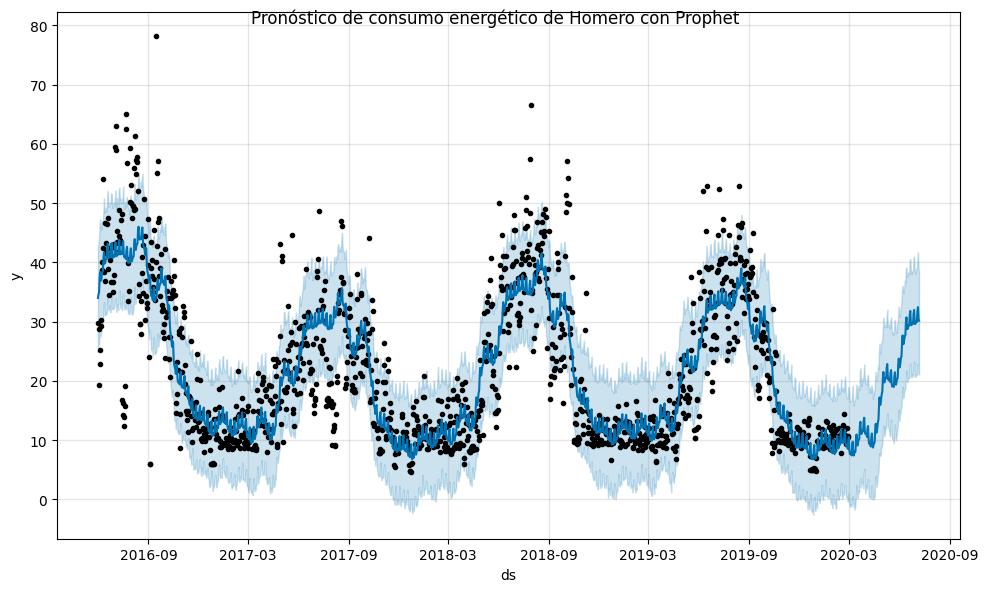

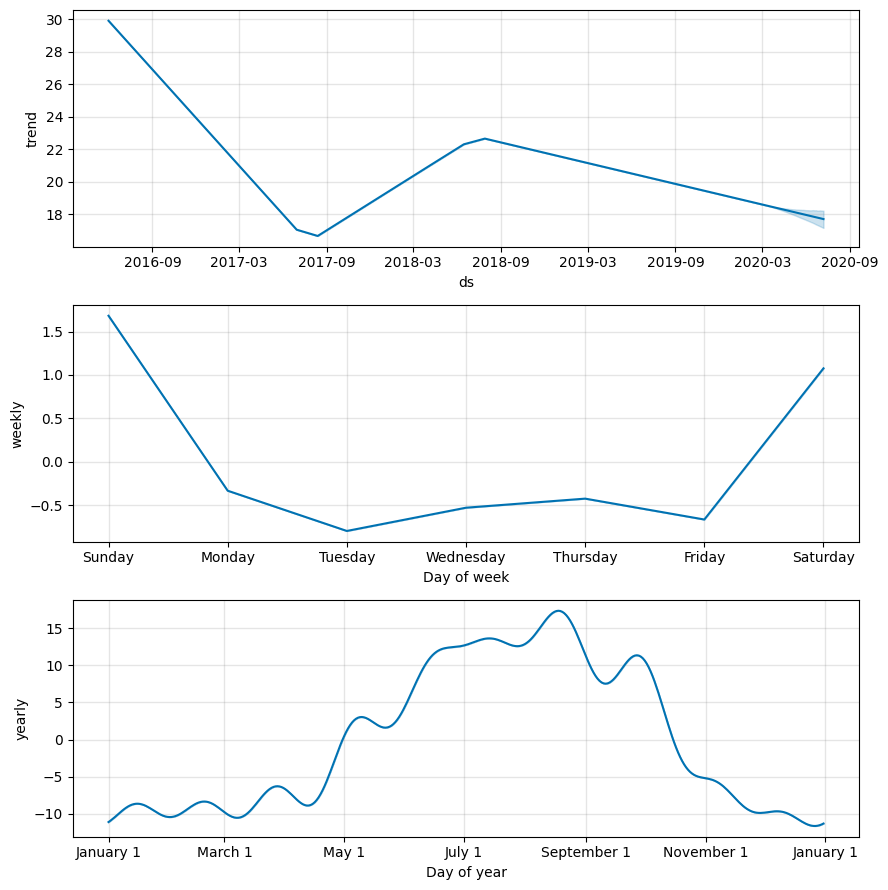

In [38]:
#CODIGO AQUI
# 1.
df = df.sort_values('date').reset_index(drop=True)
df['set'] = np.where(df.date >= pd.Timestamp('2020-03-01'), 'Test', 'Train')
df['t'] = (df['date'] - df['date'].min()).dt.days

train = df[df['set'] == 'Train'].copy()
test = df[df['set'] == 'Test'].copy()
train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test  = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

# 2.
m = Prophet()

m.fit(train)
future =  m.make_future_dataframe(periods=len(test))
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

# 3.
fig1 = m.plot(forecast)
fig1.suptitle("Pronóstico de consumo energético de Homero con Prophet", fontsize=12)

fig2 = m.plot_components(forecast)

# 4.
df_pred = pd.merge(pd.concat([train, test]), forecast[['ds', 'yhat']], on='ds', how='left')

train_mask = df_pred['ds'] <= '2020-02-29'
test_mask  = df_pred['ds'] >= '2020-03-01'

mae_train_prophet = mean_absolute_error(df_pred.loc[train_mask, 'y'], df_pred.loc[train_mask, 'yhat'])
mae_test_prophet  = mean_absolute_error(df_pred.loc[test_mask, 'y'], df_pred.loc[test_mask, 'yhat'])

print(f"MAE Prophet (train): {mae_train_prophet:.3f}")
print(f"MAE Prophet (test):  {mae_test_prophet:.3f}")

# 5.
df_pred['error'] = df_pred['y'] - df_pred['yhat']

fig3 = px.line(df_pred, x='ds', y='error',
               title='Error del modelo Prophet (Valor real - Predicho)',
               labels={'ds': 'Fecha', 'error': 'Error'})
fig3.add_hline(y=0, line_dash='dash', line_color='gray')
fig3.show()

## **Respuestas escritas**

 **Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie?**

 Con Prophet, el error MAE disminuye en el conjunto de entrenamiento (respecto al modelo estacional, de 5.3 a 4.8) pero no sucede así con el error MAE en el conjunto de prueba que incluso aumenta levemente (de 4.2 a 4.9).

 Aún así al visualizar la serie de tiempo y las componentes, se puede apreciar nuevamente un comportamiento estacional en cuanto a la estación del año como antes aunque con una forma un poco más irregular con fluctuaciones; y además una componente estacional respecto al día de semana, donde se observa que en fines de semana hay máximos de consumo energético.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

MAE (Entrenamiento): 4.745
MAE (Prueba): 4.512


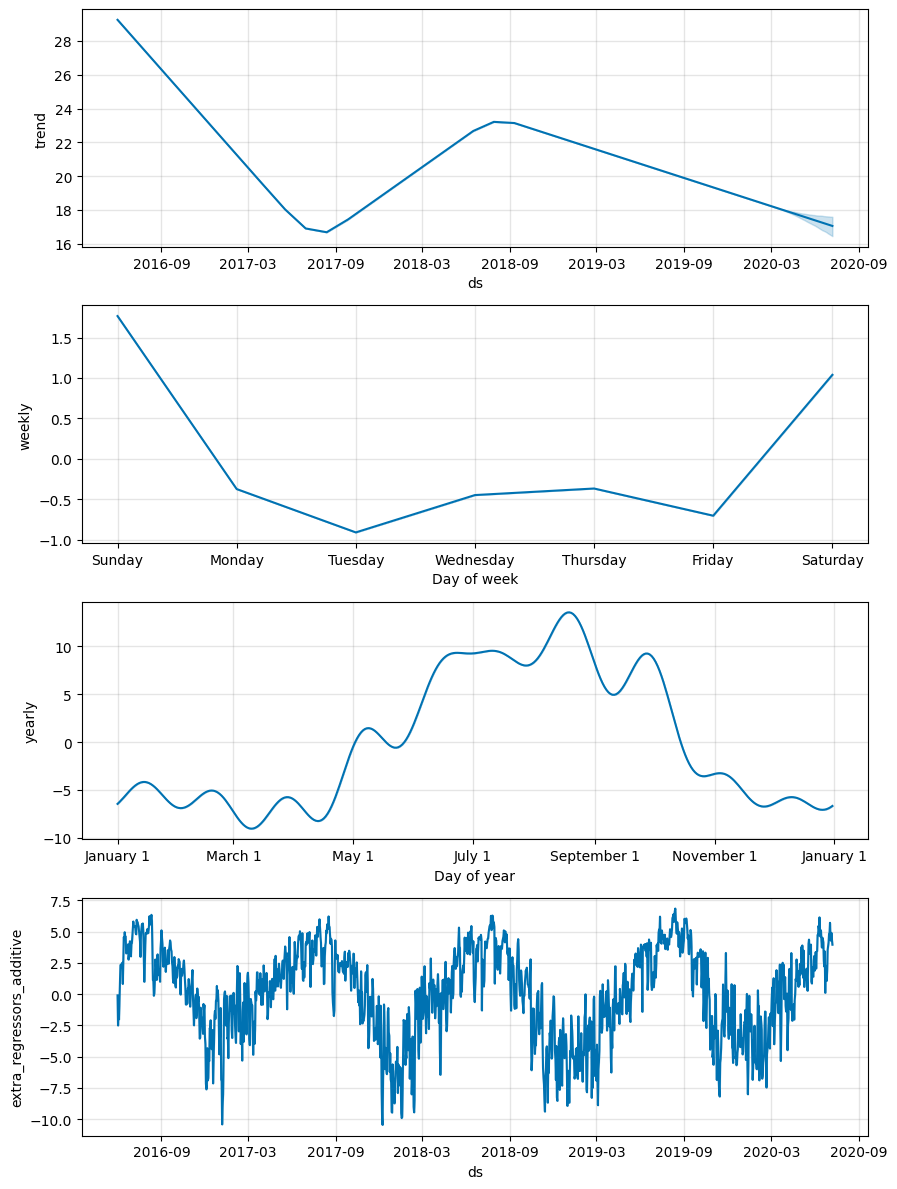

In [39]:
#CODIGO AQUI
#0.
df_energy = pd.read_csv("/content/drive/MyDrive/energia_homero.csv")
df_energy['date'] = pd.to_datetime(df_energy['date'])

df_frink = pd.read_csv("/content/drive/MyDrive/datos_frink.csv")
df_frink['date'] = pd.to_datetime(df_frink['date'])

df = pd.merge(df_energy, df_frink, on='date', how='inner')

df = df.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

# 1.
train = df[df['ds'] <= '2020-02-29']
test  = df[df['ds'] >= '2020-03-01']
regresores = ['Temp_avg', 'Temp_max', 'Temp_min', 'Hum_avg', 'Wind_avg']

m = Prophet()

for reg in regresores:
    m.add_regressor(reg)

m.fit(train[['ds', 'y'] + regresores])


future = pd.concat([train[['ds'] + regresores],
                    test[['ds'] + regresores]])

forecast = m.predict(future)

# 2.
fig = px.line()
fig.add_scatter(x=df['ds'], y=df['y'], name='Real', mode='lines')
fig.add_scatter(x=forecast['ds'], y=forecast['yhat'], name='Predicción', mode='lines')
fig.update_layout(title='Predicción de Consumo Energético con Regresores',
                  xaxis_title='Fecha', yaxis_title='Energy_kWh')
fig.show()

m.plot_components(forecast)

# 3.
forecast_full = forecast.set_index('ds')
train_pred = forecast_full.loc[train['ds'], 'yhat']
test_pred  = forecast_full.loc[test['ds'], 'yhat']

mae_train = mean_absolute_error(train['y'], train_pred)
mae_test  = mean_absolute_error(test['y'], test_pred)

print(f"MAE (Entrenamiento): {mae_train:.3f}")
print(f"MAE (Prueba): {mae_test:.3f}")

# 4.
df['yhat'] = forecast_full['yhat'].values
df['error'] = df['y'] - df['yhat']

fig_error = px.line(df, x='ds', y='error', title='Error (Valor real - Valor predicho)')
fig_error.add_hline(y=0, line_dash='dash', line_color='red')
fig_error.show()

## **Respuestas escritas**

 **¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero?**

 Se sigue observando el comportamiento estacional de la serie aunque cada vez con más fluctuaciones irregulares, sobre todo, ahora considerando las variables exógenas, aunque esta predicción resultante al incluir fluctuaciones se ajusta muy bien a la serie de tiempo del consumo de Homero.

 El error MAE sobre el conjunto de entrenamiento en este modelo es el mejor que se ha encontrado hasta el momento (4.7), y el MAE sobre el conjunto de prueba (4.5) mejoró respecto al modelo anterior con Prophet pero no respecto al modelo estacional. Aún así al mostrar mejoras respecto al modelo con Prophet, podemos decir que estas variables exógenas (temperatura promedio, máxima, mínima, humedad promedio y viento promedio) efectivamente influyen en el consumo energético de Homero.

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

<Figure size 600x400 with 0 Axes>

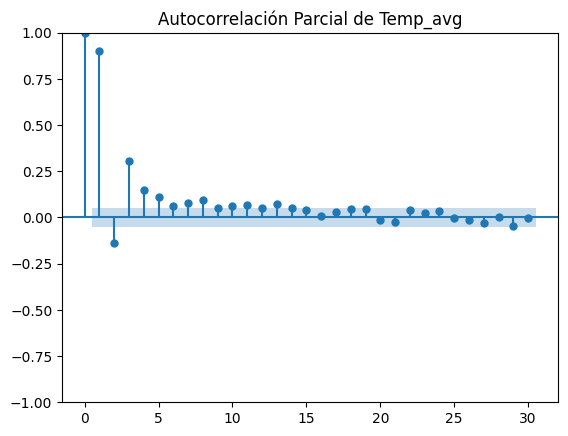

<Figure size 600x400 with 0 Axes>

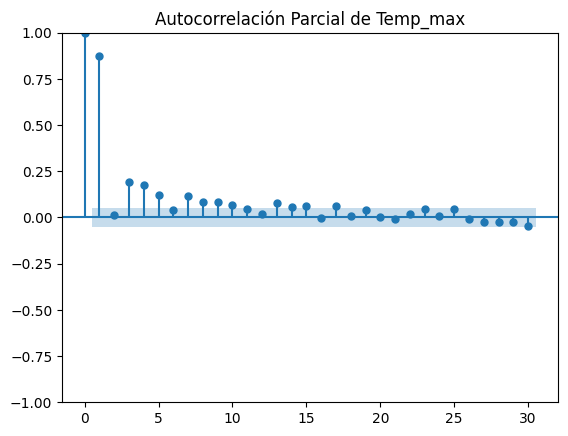

<Figure size 600x400 with 0 Axes>

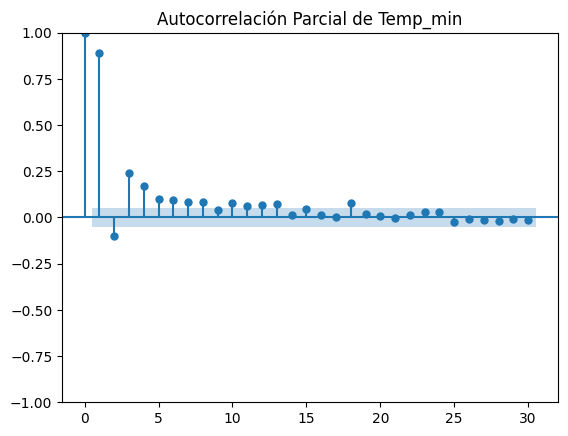

<Figure size 600x400 with 0 Axes>

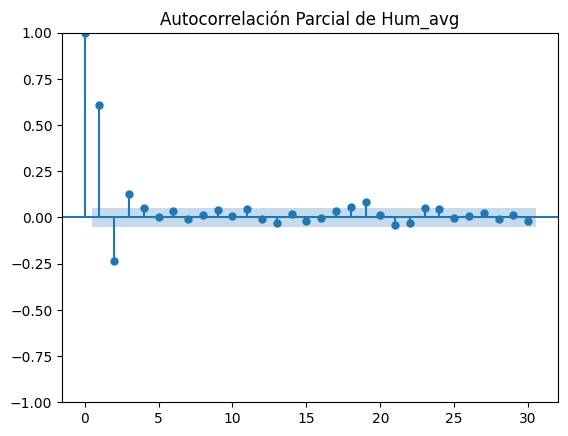

<Figure size 600x400 with 0 Axes>

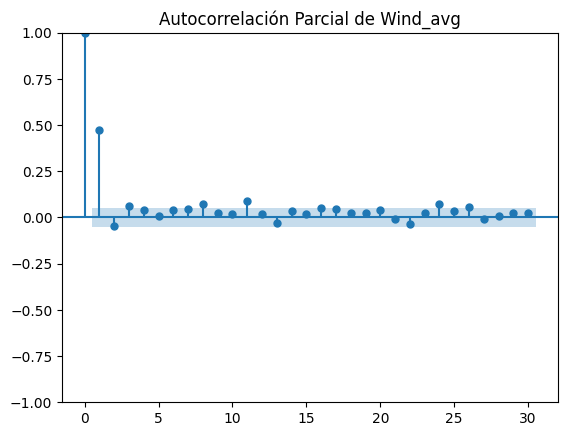

In [40]:
#CODIGO AQUI
# 1.
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

df = df.sort_values('ds')

variables_avg = ['Temp_avg', 'Temp_max', 'Temp_min', 'Hum_avg', 'Wind_avg']

for var in variables_avg:
    plt.figure(figsize=(6, 4))
    plot_pacf(df[var], lags=30, method='ywm')
    plt.title(f'Autocorrelación Parcial de {var}')
    plt.show()



In [41]:
# 2.
df_lags = df.copy()

df_lags['Temp_avg_lag1'] = df_lags['Temp_avg'].shift(1)
df_lags['Temp_avg_lag2'] = df_lags['Temp_avg'].shift(2)
df_lags['Temp_avg_lag3'] = df_lags['Temp_avg'].shift(3)
df_lags['Temp_avg_lag4'] = df_lags['Temp_avg'].shift(4)
df_lags['Temp_avg_lag5'] = df_lags['Temp_avg'].shift(5)
df_lags['Temp_avg_lag6'] = df_lags['Temp_avg'].shift(6)

df_lags['Temp_max_lag1'] = df_lags['Temp_max'].shift(1)
df_lags['Temp_max_lag2'] = df_lags['Temp_max'].shift(2)
df_lags['Temp_max_lag3'] = df_lags['Temp_max'].shift(3)
df_lags['Temp_max_lag4'] = df_lags['Temp_max'].shift(4)
df_lags['Temp_max_lag5'] = df_lags['Temp_max'].shift(5)
df_lags['Temp_max_lag6'] = df_lags['Temp_max'].shift(6)

df_lags['Temp_min_lag1'] = df_lags['Temp_min'].shift(1)
df_lags['Temp_min_lag2'] = df_lags['Temp_min'].shift(2)
df_lags['Temp_min_lag3'] = df_lags['Temp_min'].shift(3)
df_lags['Temp_min_lag4'] = df_lags['Temp_min'].shift(4)
df_lags['Temp_min_lag5'] = df_lags['Temp_min'].shift(5)
df_lags['Temp_min_lag6'] = df_lags['Temp_min'].shift(6)
df_lags['Temp_min_lag7'] = df_lags['Temp_min'].shift(7)
df_lags['Temp_min_lag8'] = df_lags['Temp_min'].shift(8)
df_lags['Temp_min_lag9'] = df_lags['Temp_min'].shift(9)

df_lags['Hum_avg_lag1'] = df_lags['Hum_avg'].shift(1)
df_lags['Hum_avg_lag2'] = df_lags['Hum_avg'].shift(2)
df_lags['Hum_avg_lag3'] = df_lags['Hum_avg'].shift(3)
df_lags['Hum_avg_lag4'] = df_lags['Hum_avg'].shift(4)

df_lags['Wind_avg_lag1'] = df_lags['Wind_avg'].shift(1)
df_lags['Wind_avg_lag2'] = df_lags['Wind_avg'].shift(2)

# 3.
cols_lags = ['Temp_avg_lag1', 'Temp_avg_lag2', 'Temp_avg_lag3', 'Temp_avg_lag4', 'Temp_avg_lag5', 'Temp_avg_lag6',
              'Temp_max_lag1', 'Temp_max_lag2', 'Temp_max_lag3', 'Temp_max_lag4', 'Temp_max_lag5', 'Temp_max_lag6',
              'Temp_min_lag1', 'Temp_min_lag2', 'Temp_min_lag3', 'Temp_min_lag4', 'Temp_min_lag5', 'Temp_min_lag6',
              'Temp_min_lag7', 'Temp_min_lag8', 'Temp_min_lag9',
             'Hum_avg_lag1', 'Hum_avg_lag2', 'Hum_avg_lag3', 'Hum_avg_lag4', 'Wind_avg_lag1', 'Wind_avg_lag2']
for col in cols_lags:
    df_lags[col].fillna(df_lags[col].mean(), inplace=True)

# 4.
from prophet import Prophet
train = df_lags[df_lags['ds'] <= '2020-02-29'].copy()
test = df_lags[df_lags['ds'] >= '2020-03-01'].copy()

regresores = ['Temp_avg', 'Temp_max', 'Temp_min', 'Hum_avg', 'Wind_avg',
              'Temp_avg_lag1', 'Temp_avg_lag2', 'Temp_avg_lag3', 'Temp_avg_lag4', 'Temp_avg_lag5', 'Temp_avg_lag6',
              'Temp_max_lag1', 'Temp_max_lag2', 'Temp_max_lag3', 'Temp_max_lag4', 'Temp_max_lag5', 'Temp_max_lag6',
              'Temp_min_lag1', 'Temp_min_lag2', 'Temp_min_lag3', 'Temp_min_lag4', 'Temp_min_lag5', 'Temp_min_lag6',
              'Temp_min_lag7', 'Temp_min_lag8', 'Temp_min_lag9',
              'Hum_avg_lag1', 'Hum_avg_lag2', 'Hum_avg_lag3', 'Hum_avg_lag4', 'Wind_avg_lag1', 'Wind_avg_lag2']

m = Prophet()
for reg in regresores:
    m.add_regressor(reg)
m.fit(train)
future = pd.concat([train[['ds'] + regresores],
                    test[['ds'] + regresores]])

forecast = m.predict(future)

/tmp/ipython-input-2928073535.py:43: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





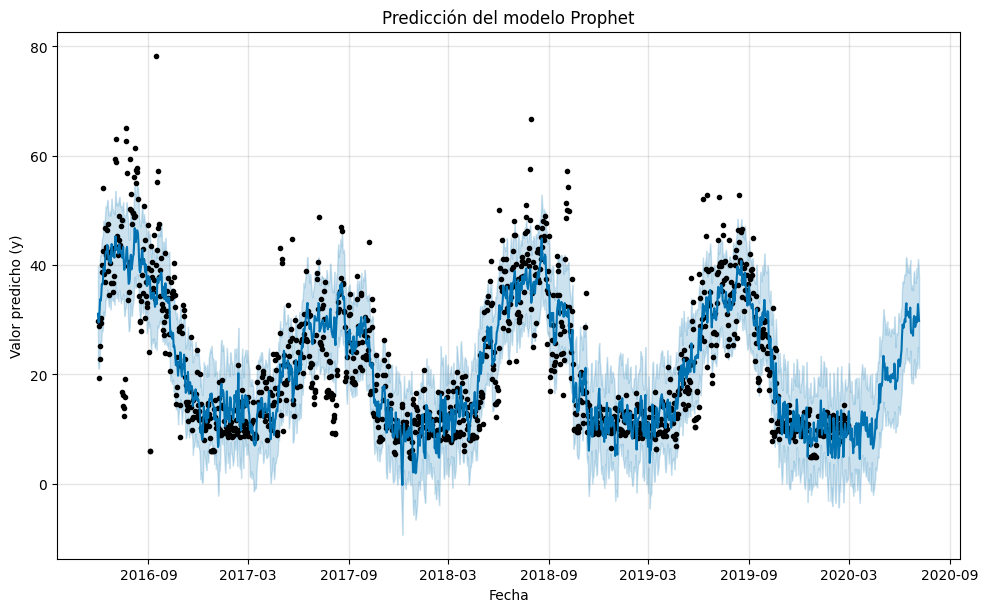

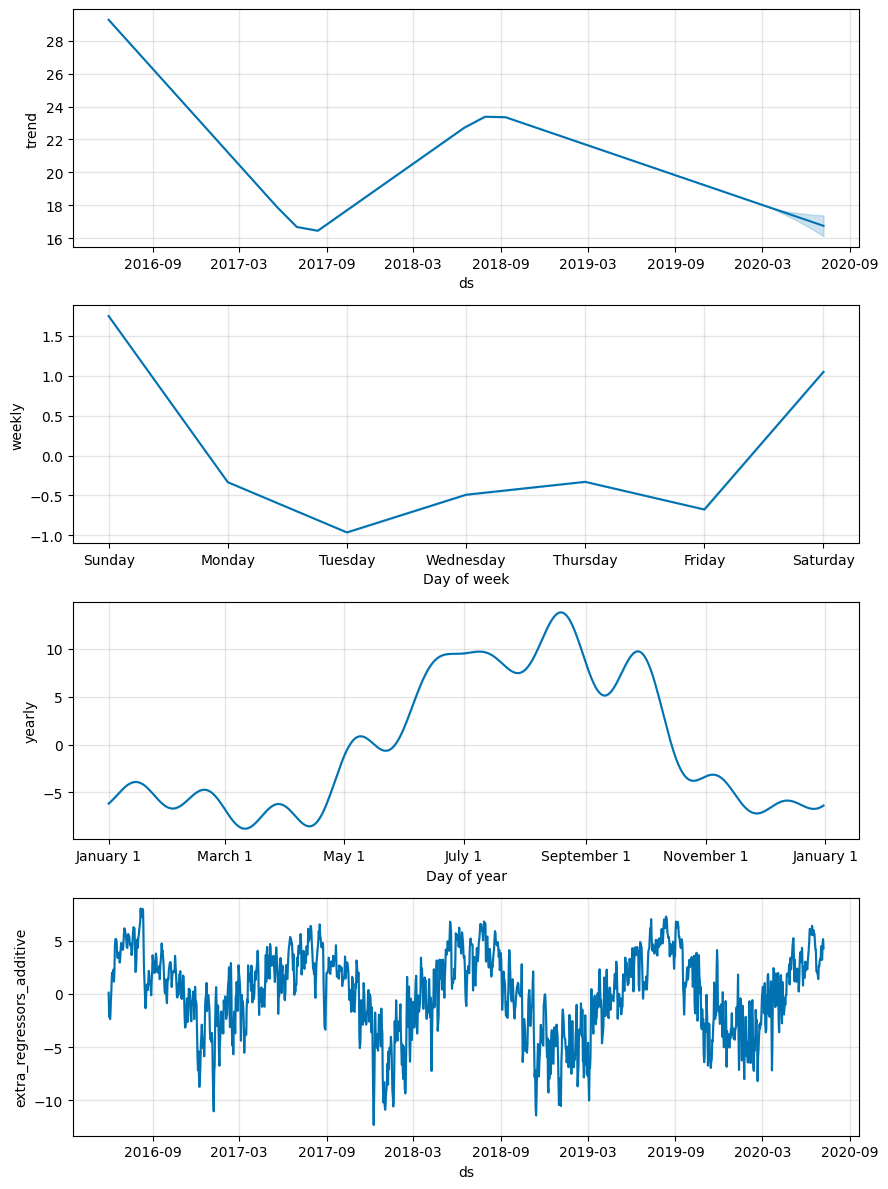

MAE en entrenamiento: 4.680
MAE en prueba: 4.745


/tmp/ipython-input-3794335312.py:27: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-3794335312.py:28: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



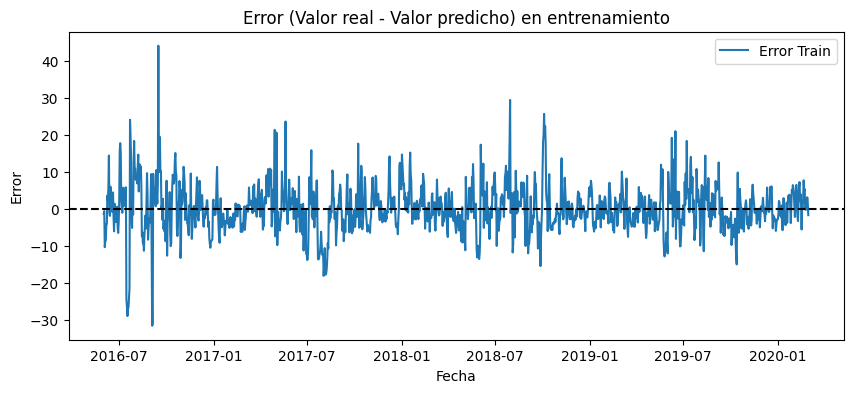

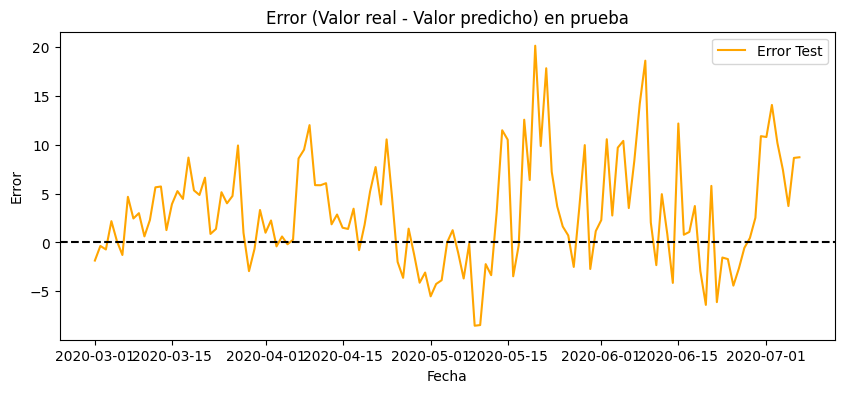

In [42]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# 4.
fig_pred = m.plot(forecast)
plt.title("Predicción del modelo Prophet")
plt.xlabel("Fecha")
plt.ylabel("Valor predicho (y)")
plt.show()

fig_comp = m.plot_components(forecast)
plt.show()

# 5.
df_pred = forecast[['ds', 'yhat']].merge(df_lags[['ds', 'y']], on='ds', how='left')

train_pred = df_pred[df_pred['ds'] <= '2020-02-29']
test_pred = df_pred[df_pred['ds'] >= '2020-03-01']

mae_train = mean_absolute_error(train_pred['y'], train_pred['yhat'])
mae_test = mean_absolute_error(test_pred['y'], test_pred['yhat'])

print(f"MAE en entrenamiento: {mae_train:.3f}")
print(f"MAE en prueba: {mae_test:.3f}")

# 6.
train_pred['error'] = train_pred['y'] - train_pred['yhat']
test_pred['error'] = test_pred['y'] - test_pred['yhat']

plt.figure(figsize=(10, 4))
plt.plot(train_pred['ds'], train_pred['error'], label='Error Train')
plt.axhline(0, color='black', linestyle='--')
plt.title("Error (Valor real - Valor predicho) en entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(test_pred['ds'], test_pred['error'], color='orange', label='Error Test')
plt.axhline(0, color='black', linestyle='--')
plt.title("Error (Valor real - Valor predicho) en prueba")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.legend()
plt.show()


## **Respuestas escritas**

 **Justifique parte 1**

 Se escogieron como variables exógenas a las temperatura promedio, máxima y mínima, humedad promedio y viento promedio, ya que estas podían tener consecuencias en el ambiente que podrían derivar en el uso de calefactores, aire acondicionado o incluso en el hecho de que la familia se haya quedado en casa por las condiciones climáticas aumentando el consumo energético.

 Para la elección de lags, se tomaron los lags hasta que cayeran en la banda de confianza y no salieran de esta, para algunos casos como los de temperatura máxima y temperatura mínima, fue un poco más complicado determinarlos ya que los lags entraban a esta banda pero luego volvían a salir.

 **¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo?**

 Nuevamente, aún vemos comportamiento estacional respecto a la estación del año y al día de la semana, y también hay un comportamiento estacional de los regresores extra en cuanto a las estaciones del año.

 La inclusión de lags mejora el MAE en entrenamiento (4.6), sin embargo, sobre el conjunto de prueba no parece mejorar respecto al modelo anterior (4.7), más bien pareciera que los modelos se atascaron en un rango de MAE para el conjunto de prueba.



## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [43]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

Tuning Prophet parameters: 100%|██████████| 48/48 [01:07<00:00,  1.40s/it]

Mejores parámetros encontrados:
{'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}

Top combinaciones ordenadas por MAE:


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,changepoint_range,MAEs
11,0.001,10.0,multiplicative,0.9,4.104906
7,0.001,5.0,multiplicative,0.9,4.105383
3,0.001,1.0,multiplicative,0.9,4.108194
22,0.010,10.0,multiplicative,0.8,4.115054
15,0.010,1.0,multiplicative,0.9,4.116829


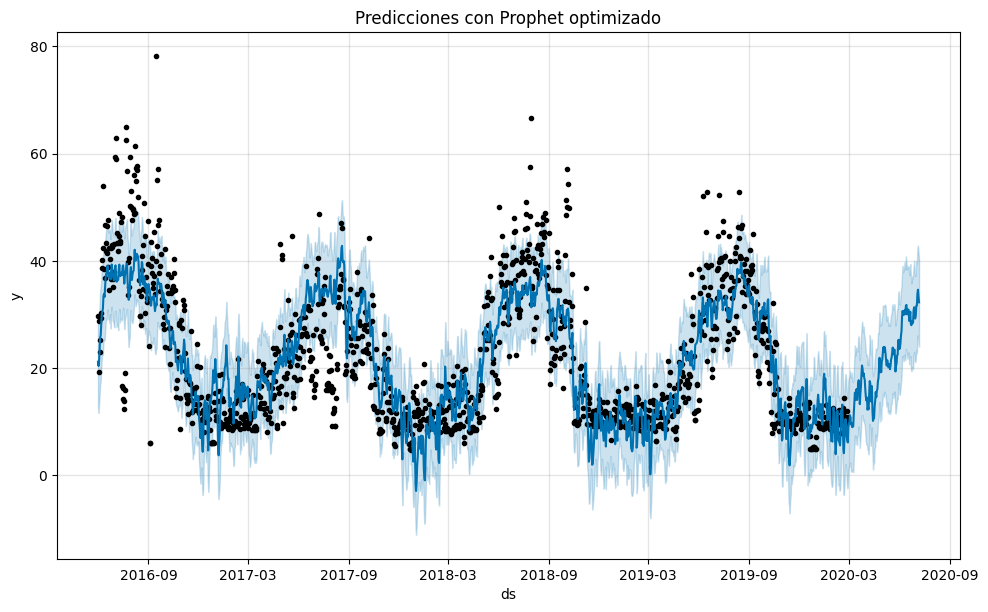

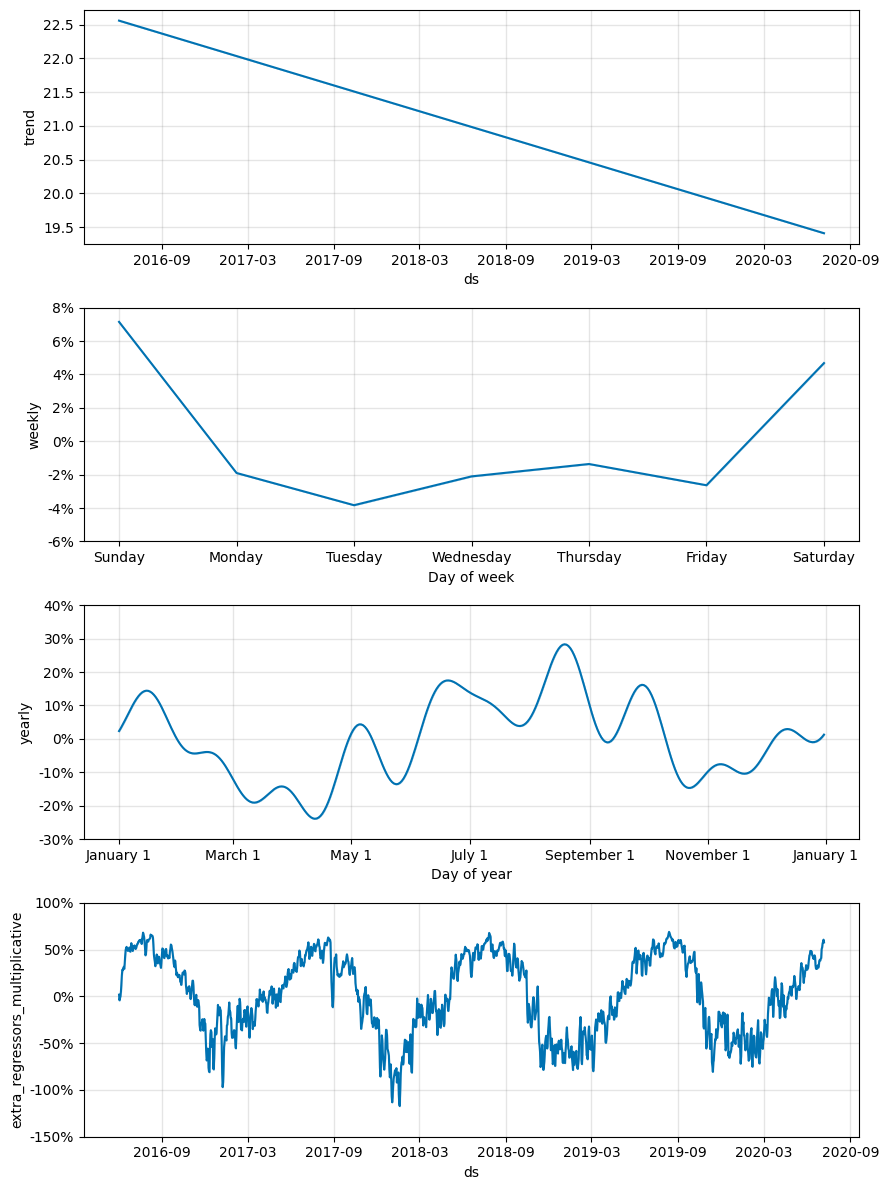

MAE Entrenamiento: 5.4515
MAE Prueba: 4.1049


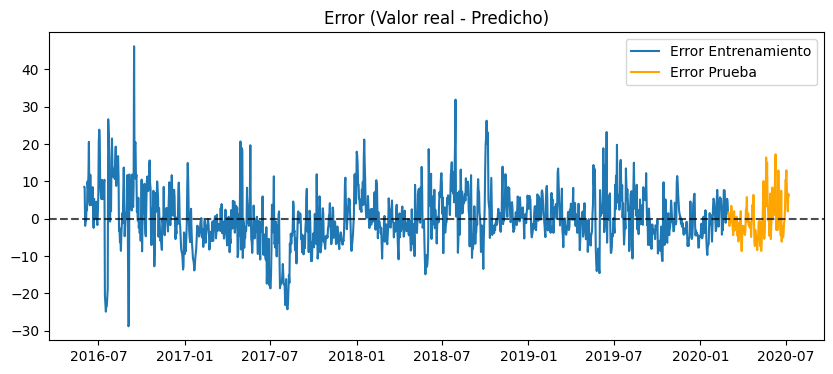

In [44]:
#CODIGO AQUI
# 1.
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 5.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9]
}

tuning_results, best_params = optimize_prophet(
    df=train,
    df_to_pred=test,
    features=regresores,
    param_grid=param_grid
)

print("Mejores parámetros encontrados:")
print(best_params)
print("\nTop combinaciones ordenadas por MAE:")
display(tuning_results.head())

# 2.
from prophet import Prophet

m_best = Prophet(**best_params)
for reg in regresores:
    m_best.add_regressor(reg)

m_best.fit(train)

future = pd.concat([train[['ds'] + regresores],
                    test[['ds'] + regresores]])
forecast = m_best.predict(future)

# 3.
fig1 = m_best.plot(forecast)
plt.title("Predicciones con Prophet optimizado")
plt.show()

fig2 = m_best.plot_components(forecast)
plt.show()

# 4.
forecast_train = forecast[forecast['ds'].isin(train['ds'])].reset_index(drop=True)
forecast_test  = forecast[forecast['ds'].isin(test['ds'])].reset_index(drop=True)

mae_train = mean_absolute_error(train['y'], forecast_train['yhat'])
mae_test = mean_absolute_error(test['y'], forecast_test['yhat'])

print(f"MAE Entrenamiento: {mae_train:.4f}")
print(f"MAE Prueba: {mae_test:.4f}")

# 5.
train_errors = train['y'].values - forecast_train['yhat'].values
test_errors = test['y'].values - forecast_test['yhat'].values

plt.figure(figsize=(10, 4))
plt.plot(train['ds'], train_errors, label='Error Entrenamiento')
plt.plot(test['ds'], test_errors, label='Error Prueba', color='orange')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title("Error (Valor real - Predicho)")
plt.legend()
plt.show()

## **Respuestas escritas**

 **Analice sus resultados**

 Con la optimización de hiperparámetros, finalmente se pudo bajar el MAE sobre el conjunto de prueba a 4.1, aunque esto significa que sobre el conjunto de entrenamiento el MAE sube a 5.3; esto puede deberse a que el modelo con los hiperparámetros no se ajusta demasiado al conjunto de entrenamiento y consigue generar predicciones con menores errores en el cconjunto de prueba.

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [45]:
!pip install surprise

In [46]:
# pip uninstall -y numpy

In [47]:
# pip install numpy==1.26.4

In [48]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [49]:
#CODIGO AQUI
df = pd.read_csv("/content/drive/MyDrive/cervezas.csv")

print("Cabecera del dataset:")
display(df.head())

print("\nValores nulos por columna:")
print(df.isnull().sum())

num_cervezas = df['beerId'].nunique()
print(f"\nCervezas evaluadas: {num_cervezas}")

num_usuarios = df['userId'].nunique()
print(f"Ciudadanos evaluados: {num_usuarios}")


Cabecera del dataset:


,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA



Valores nulos por columna:
userId       0
beerId       0
rating       0
beerName     0
beerStyle    0
dtype: int64

Cervezas evaluadas: 3747
Ciudadanos evaluados: 706


## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

In [72]:
import pandas as pd
import plotly.express as px

# 1.
num_usuarios = df['userId'].nunique()
num_productos = df['beerId'].nunique()
num_calificaciones = len(df)
faltantes = df['rating'].isnull().sum()

print(f"Número de usuarios: {num_usuarios}")
print(f"Número de productos (cervezas): {num_productos}")
print(f"Número total de calificaciones: {num_calificaciones}")
print(f"Calificaciones faltantes: {faltantes}")

media_global = df['rating'].mean()
print(f"\nMedia general de calificaciones: {media_global:.2f}")

media_por_producto = df.groupby('beerName')['rating'].mean().sort_values(ascending=False)
print("\nTop 10 cervezas mejor evaluadas:")
print(media_por_producto.head(10))

# Gráficos descriptivos con Plotly

fig1 = px.histogram(df, x='rating', nbins=20, title='Distribución de Calificaciones', color_discrete_sequence=['#f39c12'])
fig1.show()

fig2 = px.bar(x=media_por_producto.head(10).index,
              y=media_por_producto.head(10).values,
              title='Top 10 Cervezas Mejor Evaluadas (Media de Rating)',
              labels={'x': 'Cerveza', 'y': 'Media Rating'},
              color_discrete_sequence=['#27ae60'])
fig2.update_layout(xaxis_tickangle=45)
fig2.show()


# Matriz usuario-producto

user_item_matrix = df.pivot_table(index='userId', columns='beerId', values='rating')

print("\n Matriz Usuario–Producto:")
display(user_item_matrix.head())
print(f"\nDimensiones de la matriz: {user_item_matrix.shape}")


Número de usuarios: 706
Número de productos (cervezas): 3747
Número total de calificaciones: 295059
Calificaciones faltantes: 0

Media general de calificaciones: 3.86

Top 10 cervezas mejor evaluadas:
beerName
Citra DIPA                     4.669492
Trappist Westvleteren 12       4.666129
Cantillon Blåbær Lambik        4.654762
Live Oak HefeWeizen            4.639706
Heady Topper                   4.639344
Kaggen! Stormaktsporter        4.625000
Double Sunshine IPA            4.620000
King Henry                     4.615385
Pliny The Younger              4.605634
Founders CBS Imperial Stout    4.601695
Name: rating, dtype: float64



 Matriz Usuario–Producto:


beerId,5,6,7,9,10,11,14,15,17,19,...,74491,74530,74548,74579,74634,74827,74904,74986,75013,75086
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.395,3.765217,3.256849,3.478261,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,3.791908,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,3.431818,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,3.892157,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dimensiones de la matriz: (706, 3747)


## **Respuestas escritas**

Las preguntas sobre números de datos están contenidas en la ejecución anterior. Sobre cómo cambian las calificaciones a través de los productos, se observan que tienen una moda en el 4, y aunque es un gráfico de pocas barras parece ajustarse a una normal, y también el top 10 de cervezas está por sobre el 4.6

## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [73]:
#CODIGO AQUI
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1.
cervezas = df[['beerId', 'beerName', 'beerStyle']].drop_duplicates().reset_index(drop=True)

# 2.
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=10
)
X = vectorizer.fit_transform(cervezas['beerStyle'])
bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
print("\nBag of Words (cabecera):")
display(bow_df.head())

# 3.
def top5_similares(nombre_cerveza= 'Chocolate Porter'):
    if nombre_cerveza not in cervezas['beerName'].values:
        print(f"ERROR: '{nombre_cerveza}' no está en el dataset.")
        return
    idx = cervezas[cervezas['beerName'] == nombre_cerveza].index[0]
    cos_sim = cosine_similarity(X[idx], X).flatten()
    similares_idx = cos_sim.argsort()[-(5+1):][::-1][1:]
    similares = cervezas.iloc[similares_idx][['beerName', 'beerStyle']].copy()
    similares['similaridad'] = cos_sim[similares_idx]
    print(f"\nTop 5 cervezas similares a '{nombre_cerveza}':")
    display(similares)

top5_similares()

# 4.
carl_df = df[df['userId'] == 100]
mejor_cerveza_carl = carl_df.loc[carl_df['rating'].idxmax(), 'beerName']
print(f"\n Cerveza favorita de Carl (userId=100): {mejor_cerveza_carl}")

top5_similares(mejor_cerveza_carl)


Bag of Words (cabecera):


,adjunct,ale,altbier,amber,american,apa,baltic,barleywine,beer,belgian,...,vienna,warmer,wee,weizenbock,wheat,wheatwine,wild,winter,witbier,zwickel
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Top 5 cervezas similares a 'Chocolate Porter':


,beerName,beerStyle,similaridad
729,Saint Bridget's Porter,American Porter,1.0
2559,Red Eye Coffee Porter,American Porter,1.0
3176,Cowboy Coffee Porter,American Porter,1.0
3178,State Pen Porter,American Porter,1.0
1168,Arctic Rhino Coffee Porter,American Porter,1.0



 Cerveza favorita de Carl (userId=100): McNeill's Extra Special Bitter

Top 5 cervezas similares a 'McNeill's Extra Special Bitter':


,beerName,beerStyle,similaridad
3543,S.O.B. (Special Old Bitter Ale),Extra Special / Strong Bitter (ESB),1.0
3484,Phoenixx Double ESB,Extra Special / Strong Bitter (ESB),1.0
1864,XS Imperial Younger's Special Bitter,Extra Special / Strong Bitter (ESB),1.0
384,Redhook ESB,Extra Special / Strong Bitter (ESB),1.0
1847,The Wise ESB,Extra Special / Strong Bitter (ESB),1.0


## **Respuestas escritas**

La cerveza favorita de Carl es McNeill's Extra Special Bitter (contenido en la ejecución anterior).

## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

In [74]:
#CODIGO AQUI
# 1.
ratings_df = df[['userId', 'beerId', 'rating']]
reader = Reader(rating_scale=(ratings_df['rating'].min(), ratings_df['rating'].max()))
data = Dataset.load_from_df(ratings_df[['userId', 'beerId', 'rating']], reader)

# 2.
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=0.3, random_state=42)


# 3.
sim_options = {
    'name': 'cosine',
    'user_based': True
}
model_knn_user = KNNBasic(sim_options=sim_options)
model_knn_user.fit(trainset)

# 4.
predictions_user = model_knn_user.test(testset)
mae_score_user = accuracy.mae(predictions_user, verbose=True)

preds_df_user = pd.DataFrame([{
    'userId': pred.uid,
    'beerId': pred.iid,
    'rating_real': pred.r_ui,
    'rating_predicho': pred.est
} for pred in predictions_user])
display(preds_df_user.head())
print(f"MAE (modelo basado en usuarios): {mae_score_user:.4f}")


Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4639


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.200000
1,187,601,2.0,3.825000
2,112,409,3.0,3.862500
3,738,5051,4.0,4.027027
4,141,4394,4.0,3.887500


MAE (modelo basado en usuarios): 0.4639


In [75]:
# 5.

sim_options_items = {
    'name': 'cosine',
    'user_based': False
}
model_knn_item = KNNBasic(sim_options=sim_options_items)
model_knn_item.fit(trainset)

predictions_item = model_knn_item.test(testset)
mae_score_item = accuracy.mae(predictions_item, verbose=True)

preds_df_item = pd.DataFrame([{
    'userId': pred.uid,
    'beerId': pred.iid,
    'rating_real': pred.r_ui,
    'rating_predicho': pred.est
} for pred in predictions_item])

display(preds_df_item.head())
print(f" MAE (modelo basado en ítems): {mae_score_item:.4f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4640


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.200000
1,187,601,2.0,3.825000
2,112,409,3.0,3.862500
3,738,5051,4.0,4.000615
4,141,4394,4.0,3.887500


 MAE (modelo basado en ítems): 0.4640


## **Respuestas escritas**

 **¿Importa el orden?**

 Importa el orden porque surprise asume que la primera columna es la columna de usuario, y la seguna es la de producto, por tanto en otro orden, se alterarían los resultados, y no sería la implementación correcta.

 **Análisis de resultados**

 Ambos modelos (basado en usuarios, y en ítems) logran valores del MAE casi idénticos (0.46), y observando los ratings predichos, suelen acertar a los que realmente están alrededor de 4, para ratings más bajos no son tan precisos.

### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [77]:
#CODIGO AQUI
# 1.
nmf_model = NMF(random_state=42)
nmf_model.fit(trainset)
predictions_nmf = nmf_model.test(testset)

# 2.
mae_nmf = accuracy.mae(predictions_nmf, verbose=True)

nmf_results = pd.DataFrame([{
    'userId': pred.uid,
    'beerId': pred.iid,
    'rating_real': pred.r_ui,
    'rating_predicho': pred.est
} for pred in predictions_nmf])

print("\nMAE (modelo NMF):", round(mae_nmf, 4))
display(nmf_results.head())

# 3.
svd_model = SVD(random_state=42)
svd_model.fit(trainset)
predictions_svd = svd_model.test(testset)

# 4.
mae_svd = accuracy.mae(predictions_svd, verbose=True)

svd_results = pd.DataFrame([{
    'userId': pred.uid,
    'beerId': pred.iid,
    'rating_real': pred.r_ui,
    'rating_predicho': pred.est
} for pred in predictions_svd])

print("\nMAE (modelo SVD):", round(mae_svd, 4))
display(svd_results.head())

# 5.
print("\n Comparación de modelos:")
print(f"   ▪ NMF (Modelo):    {mae_nmf:.4f}")
print(f"   ▪ SVD (Modelo):    {mae_svd:.4f}")

MAE:  0.4826

MAE (modelo NMF): 0.4826


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,3.682730
1,187,601,2.0,3.714152
2,112,409,3.0,3.973135
3,738,5051,4.0,3.767895
4,141,4394,4.0,3.910392


MAE:  0.4610

MAE (modelo SVD): 0.461


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.022229
1,187,601,2.0,3.807105
2,112,409,3.0,3.885699
3,738,5051,4.0,4.014968
4,141,4394,4.0,3.926274



 Comparación de modelos:
   ▪ NMF (Modelo):    0.4826
   ▪ SVD (Modelo):    0.4610


## **Respuestas escritas**

**Análisis de resultados**

El modelo de SVD logra levemente mejores resultados que el NMF, y observando los ratings predichos, nuevamente se ve que son mejores prediciendo ratings cercanos a 4 que ratings más bajos.

Comparando los MAE, el mejor modelo es SVD con 0.461.

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [79]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

Top 3 cervezas recomendadas para Carl (userId=100):


,beerId,rating_predicho
0,325,3.941802
1,1393,3.926976
2,1884,3.763829



Predicciones de rating para 5 cervezas no evaluadas por Carl:


,beerId,rating_predicho
0,45914,3.813743
1,645,4.012848
2,8322,3.967662
3,47100,3.832679
4,42571,3.702887



Precision@10 promedio: 0.743
Recall@10 promedio: 0.340


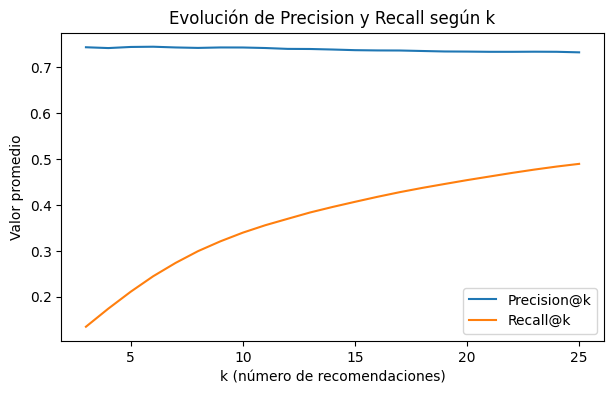

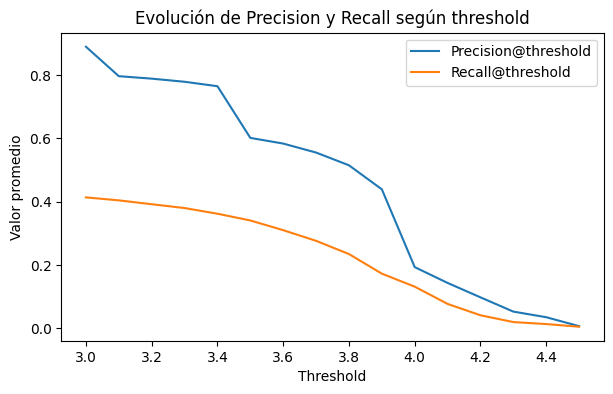


Matriz completa de ratings (sin nulos):


,995,58695,4083,40310,1904,409,16858,25061,14309,13906,...,1145,708,45308,25095,4957,47589,62792,18432,4753,6428
144,3.871513,3.622858,3.842587,3.636771,3.919137,3.754595,3.686757,3.706330,3.722344,3.778792,...,3.657975,3.769330,3.695747,3.729386,3.764388,3.804747,3.440846,3.376007,3.698321,3.498709
63,4.131842,4.034455,4.233354,4.016627,4.262557,4.097508,4.041871,4.018054,3.997604,4.119530,...,3.955044,4.137833,4.080694,4.025308,4.143937,4.039100,3.805570,3.679589,4.081408,3.932017
147,3.979455,3.897711,4.086853,3.851518,4.112932,3.953385,3.885829,3.867270,3.852832,3.949128,...,3.797175,3.995989,3.943278,3.887667,4.008618,3.910191,3.680414,3.539807,3.943376,3.765250
4261,3.874472,3.820959,3.948819,3.655140,4.013410,3.713958,3.734862,3.843192,3.710188,3.799044,...,3.573084,3.878221,3.733281,3.613957,3.892369,3.604023,3.425362,3.360017,3.668916,3.689851
140,4.044295,3.965228,4.141565,3.924157,4.173485,4.014227,3.953092,3.921410,3.919040,4.011564,...,3.856818,4.048115,3.994935,3.954797,4.064306,3.969619,3.738268,3.591548,4.010203,3.831489


In [80]:
#Desarrolle su código aquí
import random

# 1.
def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    for uid, user_ratings in top_n.items():
        seen = set()
        top_n[uid] = [
            (iid, est)
            for iid, est in sorted(user_ratings, key=lambda x: x[1], reverse=True)
            if not (iid in seen or seen.add(iid))
        ][:n]
    return top_n


predictions = predictions_svd

top_n = get_top_n(predictions, n=3)
top_carl = pd.DataFrame(top_n[100], columns=["beerId", "rating_predicho"])
print("Top 3 cervezas recomendadas para Carl (userId=100):")
display(top_carl)

# 2.
rated_by_carl = set(df[df["userId"] == 100]["beerId"])
all_beers = set(df["beerId"])
not_rated = list(all_beers - rated_by_carl)

random.seed(42)
sample_beers = random.sample(not_rated, 5)

pred_carl = [svd_model.predict(100, beer) for beer in sample_beers]
pred_carl_df = pd.DataFrame({
    "beerId": sample_beers,
    "rating_predicho": [p.est for p in pred_carl]
})
print("\nPredicciones de rating para 5 cervezas no evaluadas por Carl:")
display(pred_carl_df)

# 3.
precisions, recalls = precision_recall_at_k(predictions, k=10, threshold=3.5)
precision_mean = np.mean(list(precisions.values()))
recall_mean = np.mean(list(recalls.values()))
print(f"\nPrecision@10 promedio: {precision_mean:.3f}")
print(f"Recall@10 promedio: {recall_mean:.3f}")

# 4.
ks = range(3, 26)
prec_list, rec_list = [], []

for k in ks:
    p, r = precision_recall_at_k(predictions, k=k, threshold=3.5)
    prec_list.append(np.mean(list(p.values())))
    rec_list.append(np.mean(list(r.values())))

plt.figure(figsize=(7, 4))
plt.plot(ks, prec_list, label="Precision@k")
plt.plot(ks, rec_list, label="Recall@k")
plt.xlabel("k (número de recomendaciones)")
plt.ylabel("Valor promedio")
plt.title("Evolución de Precision y Recall según k")
plt.legend()
plt.show()


# 5.
thresholds = np.arange(3.0, 4.6, 0.1)
prec_thr, rec_thr = [], []

for t in thresholds:
    p, r = precision_recall_at_k(predictions, k=10, threshold=t)
    prec_thr.append(np.mean(list(p.values())))
    rec_thr.append(np.mean(list(r.values())))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, prec_thr, label="Precision@threshold")
plt.plot(thresholds, rec_thr, label="Recall@threshold")
plt.xlabel("Threshold")
plt.ylabel("Valor promedio")
plt.title("Evolución de Precision y Recall según threshold")
plt.legend()
plt.show()

# 6.
users = df["userId"].unique()
beers = df["beerId"].unique()

matrix = pd.DataFrame(index=users, columns=beers)

for uid in users:
    for iid in beers:
        pred = svd_model.predict(uid, iid).est
        matrix.loc[uid, iid] = pred

matrix = matrix.astype(float)

print("\nMatriz completa de ratings (sin nulos):")
display(matrix.head())

## **Respuestas escritas**

**Analice sus resultados. ¿Es un buen modelo?**

Tiene una precisión aceptable de 0.74, es decir alrededor de 3 de cada 4 recomendaciones son eficaces o relevantes, pero en cuanto al recall, que es de 0.34, habla de que el modelo tiene una baja cobertura en seleccionar cervezas relevantes en sus top 10. Por tanto, es un buen modelo, si se quiere recomendar cervezas buenas (según todos en general) a un usuario, pero es un modelo si quiere encontrar la mayor cantidad de cervezas que le gusten a un usuario en particular.

**Analice el comportamiento de las curvas de precisión y recall en función de k**

La precisión se mantiene constante alrededor de 0.75, mientras que el recall crece desde 0.1 a 0.5, es decir al aumentar k, logra aumentar las cervezas relevantes entre las recomendaciones para un usuario, sacrificando muy levemente la precisión

**Analice el comportamiento de las curvas de precisión y recall en función de threshold**

A medida que sube el treeshold, tanto la precisión como el recall empiezan a decaer hasta 0. Esto se explica porque a medida que crece treeshold, crece el umbral del modelo para considerar relevante una predicción, por tanto, cada vez menos recomendaciones de cervezas lo alcanzan (la precisión baja) y hay menor cobertura de cervezas superando el umbral (el recall baja)

# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
